In [1]:
import torch
import torch.multiprocessing as mp
from gymnasium.vector import AsyncVectorEnv
import numpy as np
from env import mbb
from models import ppo
import os
import pandas as pd
import matplotlib.pyplot as plt
import logging
from datetime import datetime
import random

In [2]:

# Configure logging
logging.basicConfig(
    level=logging.INFO,  # Set to DEBUG for more detailed logs
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("reward_logs.log"),  # Log to a file
        logging.StreamHandler()  # Also log to console
    ]
)


print("============================================================================================")
device = torch.device('cpu')
if(torch.cuda.is_available()): 
    device = torch.device('cuda:0') 
    torch.cuda.empty_cache()
    print("Device set to : " + str(torch.cuda.get_device_name(device)))
else:
    print("Device set to : cpu")  
print("============================================================================================")


Device set to : NVIDIA GeForce RTX 4070 Laptop GPU


In [3]:
def select_ensemble_action(state, agents):
    actions = []
    for agent in agents:
        action, _, _ = agent.select_action(state)
        actions.append(action)
    actions = np.array(actions)
    
    # Majority voting for discrete actions
    final_actions = []
    for i in range(actions.shape[1]):
        counts = np.bincount(actions[:, i])
        final_actions.append(np.argmax(counts))
    return np.array(final_actions)

In [4]:
'''    K_epochs: 19
    eps_clip: 0.1560054116302963
    gamma: 0.9541033156990307
    lr_actor: 1.534069415636938e-05
    lr_critic: 5.7160372295955113e-05
    gae_lambda: 0.8486921477985604
    w_compliance: 0.7742947255672104
    w_density_high: 5.634912144964039
    w_density_low: 0.6367337858475912
    w_total_mass: 1.4913119246676363
    w_entropy: 0.9018999960713338'''

'    K_epochs: 19\n    eps_clip: 0.1560054116302963\n    gamma: 0.9541033156990307\n    lr_actor: 1.534069415636938e-05\n    lr_critic: 5.7160372295955113e-05\n    gae_lambda: 0.8486921477985604\n    w_compliance: 0.7742947255672104\n    w_density_high: 5.634912144964039\n    w_density_low: 0.6367337858475912\n    w_total_mass: 1.4913119246676363\n    w_entropy: 0.9018999960713338'

In [5]:


def make_beam_env():
    beam_type = random.choice([1,2,3,4,5,6,7,8,9])
    # beam_type = 1
    return mbb.BeamOptimizationEnv(width=6, height=6, density=0.4,  optimal_density=0.5, reward_weights=None, beam_type = beam_type)

if __name__ == "__main__":
    # Set the start method to 'spawn' to avoid CUDA issues
    mp.set_start_method('spawn', force=True)

    # Hyperparameters
    env_name = "BeamOptimizationEnv"
    env = mbb.BeamOptimizationEnv(width=6, height=6, density=0.4,  optimal_density=0.5)
    has_continuous_action_space = False
    max_ep_len = env.width * env.height * 10 

    action_std = None  

    
    best_params = {
        'K_epochs': 3,
        'eps_clip': 0.1,
        'gamma': 0.9939332339275259,
        'lr_actor': 0.0007628325751692734,
        'lr_critic': 0.0007
    }
    #''' designed for original mbb_beam
    best_params = {
        'K_epochs': 100,
        'eps_clip': 0.15,
        'gamma': 0.95,
        'lr_actor': 0.00015,
        'lr_critic': 0.00057
    }#'''
   #


    update_timestep = max_ep_len  # Update PPO every 'update_timestep' timesteps

    K_epochs = best_params['K_epochs']
    eps_clip = best_params['eps_clip']
    gamma = best_params['gamma']
    lr_actor = best_params['lr_actor']
    lr_critic = best_params['lr_critic']
    random_seed = 0 
    num_envs = 32
    env_fns = [make_beam_env for _ in range(num_envs)]  # Pass the function itself
    vector_env = AsyncVectorEnv(env_fns)
    print(type(vector_env))
    # Get state and action dimensions
    state_dim = vector_env.single_observation_space.shape[0]
    print(f"State dimension: {state_dim}")

    if has_continuous_action_space:
        action_dim = vector_env.single_action_space.shape[0]
    else:
        action_dim = vector_env.single_action_space.n

    # Initialize PPO agent
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ppo_agent = ppo.PPO(
        state_dim=state_dim,
        action_dim=action_dim,
        lr_actor=lr_actor,
        lr_critic=lr_critic,
        gamma=gamma,
        K_epochs=K_epochs,
        eps_clip=eps_clip,
        has_continuous_action_space=has_continuous_action_space,
        action_std_init=action_std,
        gae_lambda=0.95,
        num_envs=num_envs,
        device=device
    )


    # track total training time
    start_time = datetime.now().replace(microsecond=0)
    print("Started training at (GMT) : ", start_time)

    print("============================================================================================")
    ###################### logging ######################

    #### log files for multiple runs are NOT overwritten

    log_dir = "PPO_logs"
    if not os.path.exists(log_dir):
        os.makedirs(log_dir)

    log_dir = log_dir + '/' + env_name + '/'
    if not os.path.exists(log_dir):
        os.makedirs(log_dir)


    #### get number of log files in log directory
    run_num = 0
    current_num_files = next(os.walk(log_dir))[2]
    run_num = len(current_num_files)


    #### create new log file for each run 
    log_f_name = log_dir + '/PPO_' + env_name + "_log_" + str(run_num) + ".csv"

    print("current logging run number for " + env_name + " : ", run_num)
    print("logging at : " + log_f_name)

    #####################################################


    ################### checkpointing ###################

    run_num_pretrained = 0      #### change this to prevent overwriting weights in same env_name folder

    directory = "PPO_preTrained"
    if not os.path.exists(directory):
        os.makedirs(directory)

    directory = directory + '/' + env_name + '/'
    if not os.path.exists(directory):
        os.makedirs(directory)


    checkpoint_path = directory + "PPO_{}_{}_{}.pth".format(env_name, random_seed, run_num_pretrained)
    print("save checkpoint path : " + checkpoint_path)

    #####################################################


    # logging file
    log_f = open(log_f_name,"w+")
    log_f.write('episode,timestep,reward\n')
    print_running_reward = 0
    log_running_reward = 0
    print_running_episodes = 0
    max_ep_len = env.width * env.height * 10 
    max_training_timesteps = int(5e6)  # Total number of training timesteps

    print_freq = max_ep_len  *2      # Print avg reward every 'print_freq' timesteps
    log_freq = max_ep_len *2        # Log avg reward every 'log_freq' timesteps
    save_model_freq = int(2e3) 
    log_running_episodes = 0



    #### Initialize Logging Variables ####
    timestep = 0
    running_reward = 0
    avg_length = 0
    reward_history = []
    i_episode = 0

    #### Training Loop ####   NEED TO IMPLEMENT EARLY STOPPING TO PREVENT OVERFITTING
    while timestep < max_training_timesteps+1:
        # Reset all environments and unpack the observations and info
        state, info = vector_env.reset()
        # print(f"shape of state afer resetting is {state.shape}")
        ep_reward = np.zeros(num_envs)
        done_flags = np.array([False] * num_envs)

        for t_step in range(1, max_ep_len + 1):
            # Select actions for all environments
            actions, logprobs, state_values = ppo_agent.select_action(state)
            # print(f"shape of state inside the trainign loops is {state.shape}")
            # print(f"actions is of shape {actions.shape}")
            # Take actions in all environments
            try:
                states_new, rewards, dones, truncateds, infos = vector_env.step(actions)
                #print(f"action takens")
            except Exception as e:
                print(f"Error during environment step: {e}")
                break

            # Combine done flags
            dones_combined = np.logical_or(dones, truncateds)

            # Store transitions in the buffer
            if not ppo_agent.has_continuous_action_space:
                # For discrete actions
                actions_tensor = torch.LongTensor(actions).to(ppo_agent.device)
            else:
                # For continuous actions
                actions_tensor = torch.FloatTensor(actions).to(ppo_agent.device)

            ppo_agent.buffer.store(
                states=torch.FloatTensor(state).to(ppo_agent.device),
                actions=actions_tensor,
                logprobs=logprobs,
                rewards=torch.FloatTensor(rewards).to(ppo_agent.device),
                state_values=state_values,
                is_terminals=torch.tensor(dones_combined, dtype=torch.bool).to(ppo_agent.device)
            )
            ep_reward += rewards
            state = states_new
            #timestep += num_envs
            timestep +=1  
            # Update PPO agent if enough timesteps have passed

            # update PPO agent

            if timestep % update_timestep == 0:
                ppo_agent.update()

            # if continuous action space; then decay action std of ouput action distribution
            if has_continuous_action_space and timestep % action_std_decay_freq == 0:
                ppo_agent.decay_action_std(action_std_decay_rate, min_action_std)

            # log in logging file
            if timestep % log_freq == 0:

                # log average reward till last episode
                log_avg_reward = log_running_reward / log_running_episodes
                log_avg_reward = np.mean(log_avg_reward)
                log_avg_reward = round(log_avg_reward, 4)

                log_f.write('{},{},{}\n'.format(i_episode, timestep, log_avg_reward))
                log_f.flush()

                log_running_reward = 0
                log_running_episodes = 0


            # printing average reward
            if timestep % print_freq == 0:
                # print average reward till last episode
                print_avg_reward = print_running_reward / print_running_episodes
                print_avg_reward = np.mean(print_avg_reward)
                print_avg_reward = round(print_avg_reward, 2)

                print("Episode : {} \t\t Timestep : {} \t\t Average Reward : {}".format(i_episode, timestep, print_avg_reward))

                print_running_reward = 0
                print_running_episodes = 0
                
            # save model weights
            if timestep % save_model_freq == 0:
                print("--------------------------------------------------------------------------------------------")
                print("saving model at : " + checkpoint_path)
                ppo_agent.save(checkpoint_path)
                print("model saved")
                print("Elapsed Time  : ", datetime.now().replace(microsecond=0) - start_time)
                print("--------------------------------------------------------------------------------------------")
                
            # break; if the episode is over
            if dones_combined.all():
                break

        print_running_reward += ep_reward
        print_running_episodes += 1

        log_running_reward += ep_reward
        log_running_episodes += 1

        i_episode += 1


    log_f.close()
    env.close()




    # print total training time
    print("============================================================================================")
    end_time = datetime.now().replace(microsecond=0)
    print("Started training at (GMT) : ", start_time)
    print("Finished training at (GMT) : ", end_time)
    print("Total training time  : ", end_time - start_time)
    print("============================================================================================")

<class 'gymnasium.vector.async_vector_env.AsyncVectorEnv'>
State dimension: 134
Started training at (GMT) :  2024-12-31 18:05:35
current logging run number for BeamOptimizationEnv :  0
logging at : PPO_logs/BeamOptimizationEnv//PPO_BeamOptimizationEnv_log_0.csv
save checkpoint path : PPO_preTrained/BeamOptimizationEnv/PPO_BeamOptimizationEnv_0_0.pth
Episode : 1 		 Timestep : 720 		 Average Reward : -135.94
Episode : 3 		 Timestep : 1440 		 Average Reward : -132.37
--------------------------------------------------------------------------------------------
saving model at : PPO_preTrained/BeamOptimizationEnv/PPO_BeamOptimizationEnv_0_0.pth
model saved
Elapsed Time  :  0:00:17
--------------------------------------------------------------------------------------------
Episode : 5 		 Timestep : 2160 		 Average Reward : -123.65
Episode : 7 		 Timestep : 2880 		 Average Reward : -119.98
Episode : 9 		 Timestep : 3600 		 Average Reward : -121.54
----------------------------------------------

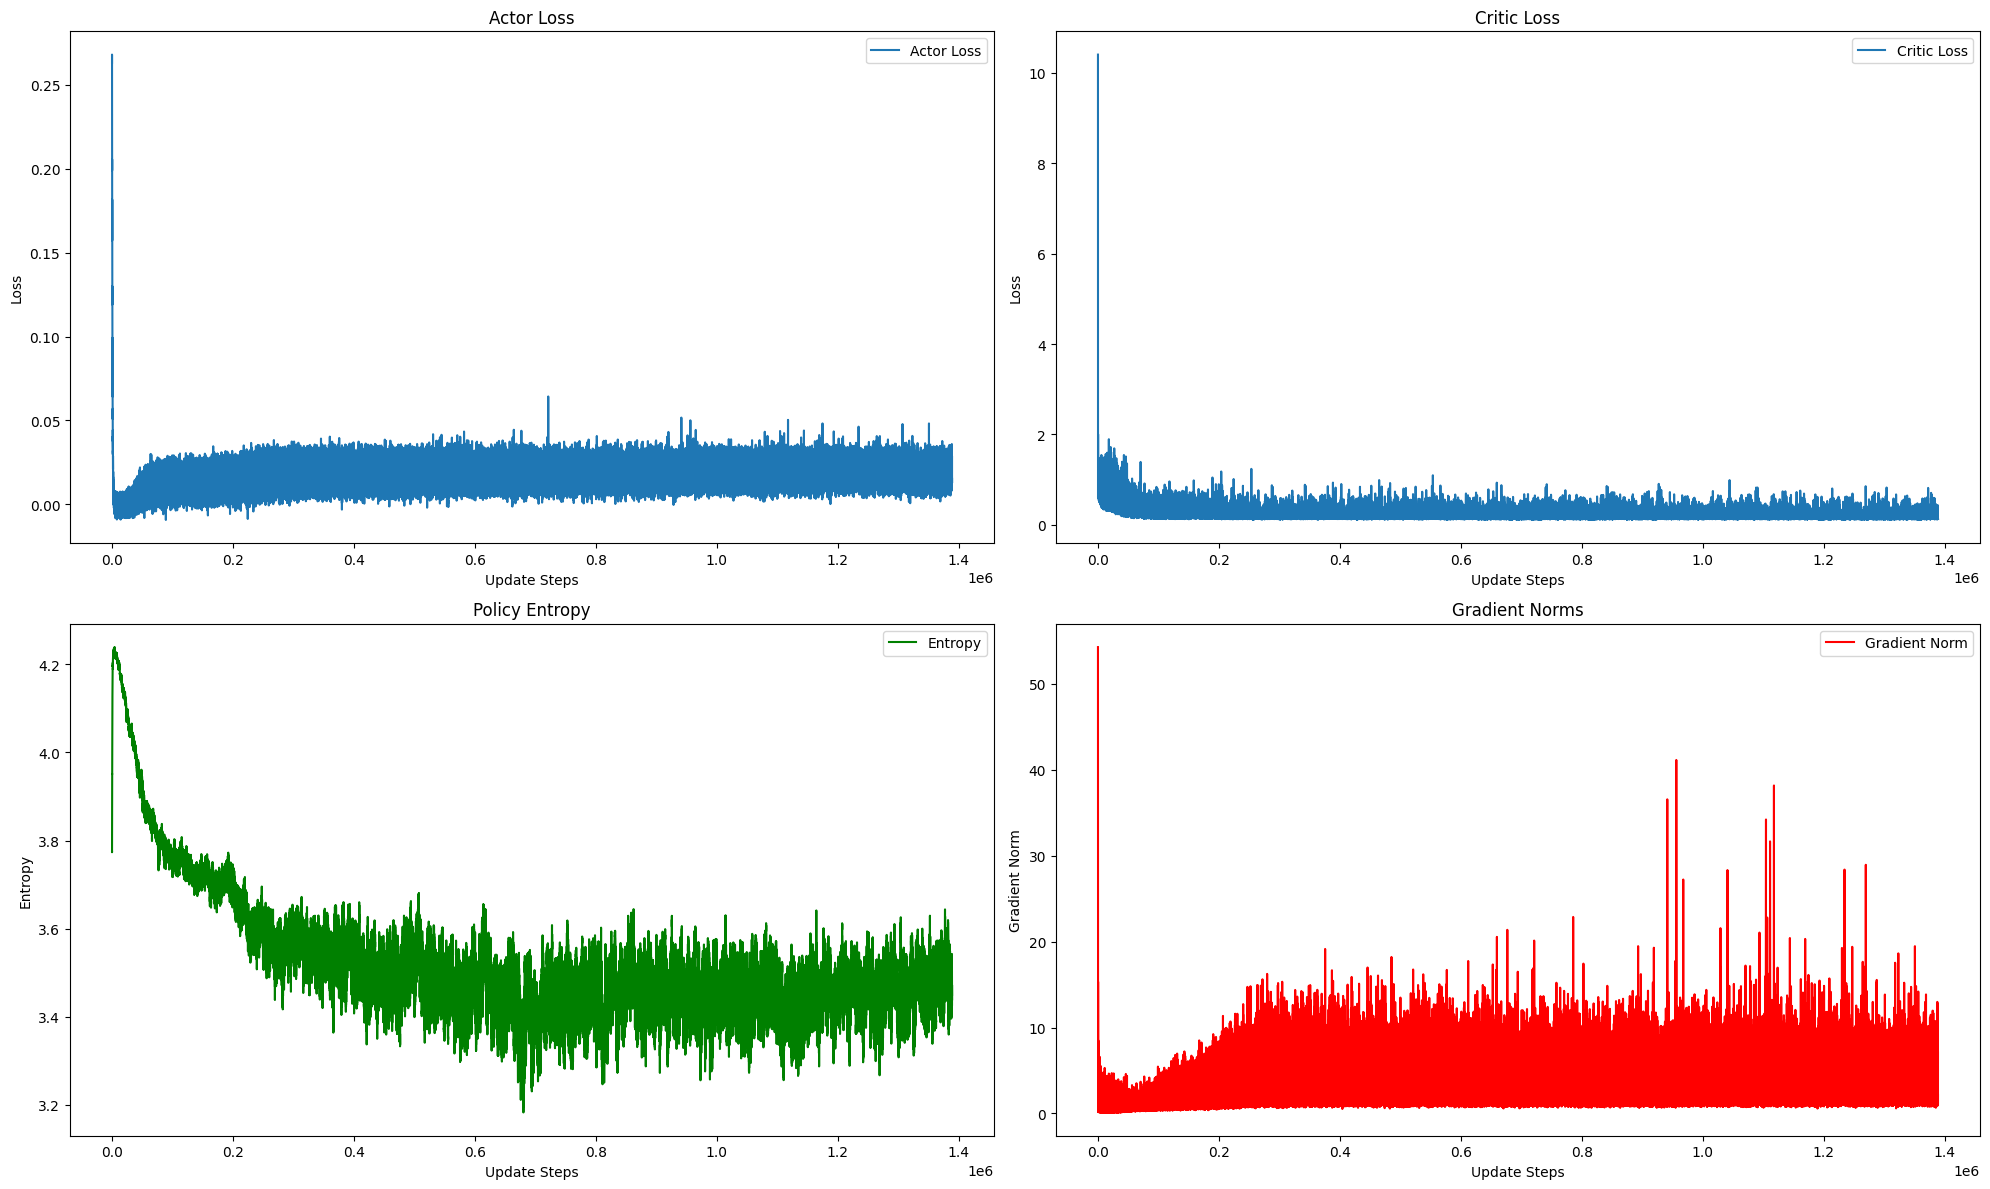

In [6]:
ppo_agent.plot_metrics()

In [7]:
# ppo_agent.plot_advantage_distribution_window()
# ppo_agent.plot_reward_distribution_window()
# ppo_agent.plot_advantage_vs_reward()

 state dim is 134
 action dim is 72
loading network from : PPO_preTrained/BeamOptimizationEnv/PPO_BeamOptimizationEnv_0_0.pth
--------------------------------------------------------------------------------------------


2025-01-01 15:35:25,640 - INFO - Episode done: Step: 360 | Action: 57 | Raw Reward: 0.14 | Scaled Reward: 0.1238 | Reward Compliance: -0.31 | Reward Density High: 0.15 | Reward Density Low: 0.15 | Reward Total Mass: -0.00 | Reward Entropy: 0.15 | Total Reward: 0.1481 | Compliance: 30.81 | Constraint: 0.50


number of changed cells in the episode is 360
Episode: 1 		 Reward: 15.87


2025-01-01 15:35:26,263 - INFO - Episode done: Step: 360 | Action: 24 | Raw Reward: 0.09 | Scaled Reward: 0.0832 | Reward Compliance: -0.35 | Reward Density High: 0.14 | Reward Density Low: 0.14 | Reward Total Mass: -0.00 | Reward Entropy: 0.16 | Total Reward: 0.1175 | Compliance: 35.36 | Constraint: 0.49


number of changed cells in the episode is 360
Episode: 2 		 Reward: 18.51


...

number of changed cells in the episode is 360
Episode: 8 		 Reward: 20.77


2025-01-01 15:35:30,856 - INFO - Episode done: Step: 360 | Action: 49 | Raw Reward: 0.05 | Scaled Reward: 0.0474 | Reward Compliance: -0.40 | Reward Density High: 0.14 | Reward Density Low: 0.14 | Reward Total Mass: -0.00 | Reward Entropy: 0.16 | Total Reward: 0.0887 | Compliance: 39.70 | Constraint: 0.50


number of changed cells in the episode is 360
Episode: 9 		 Reward: 11.44


2025-01-01 15:35:31,408 - INFO - Episode done: Step: 360 | Action: 52 | Raw Reward: 0.14 | Scaled Reward: 0.1258 | Reward Compliance: -0.31 | Reward Density High: 0.16 | Reward Density Low: 0.16 | Reward Total Mass: -0.00 | Reward Entropy: 0.14 | Total Reward: 0.1495 | Compliance: 31.11 | Constraint: 0.49


number of changed cells in the episode is 360
Episode: 10 		 Reward: 19.96
average test reward : 14.2
loading data from : PPO_logs/BeamOptimizationEnv//PPO_BeamOptimizationEnv_log_0.csv
data shape :  (6944, 3)
--------------------------------------------------------------------------------------------
figure saved at :  PPO_figs/BeamOptimizationEnv//PPO_BeamOptimizationEnv_fig_0.png


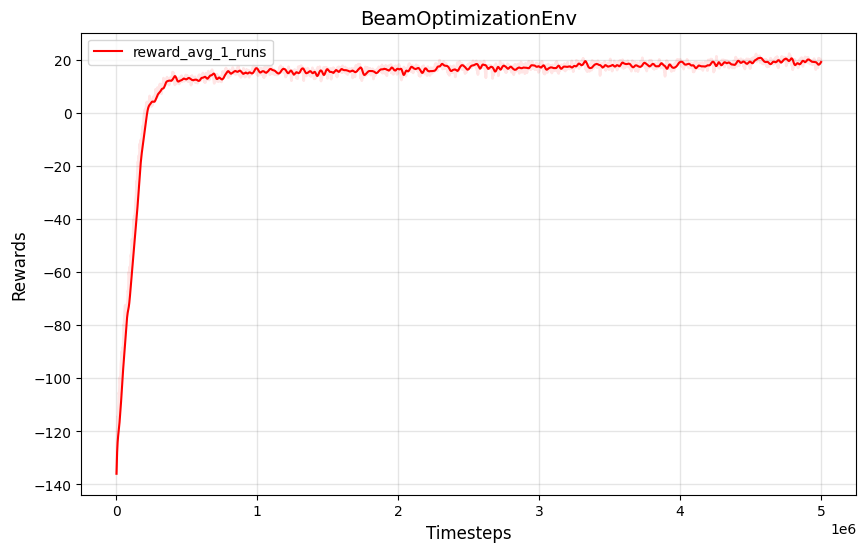

Loading network from: PPO_preTrained/BeamOptimizationEnv/PPO_BeamOptimizationEnv_0_0.pth


2025-01-01 15:35:32,158 - INFO - Episode done: Step: 360 | Action: 15 | Raw Reward: 0.13 | Scaled Reward: 0.1183 | Reward Compliance: -0.31 | Reward Density High: 0.16 | Reward Density Low: 0.16 | Reward Total Mass: -0.00 | Reward Entropy: 0.13 | Total Reward: 0.1440 | Compliance: 31.27 | Constraint: 0.50


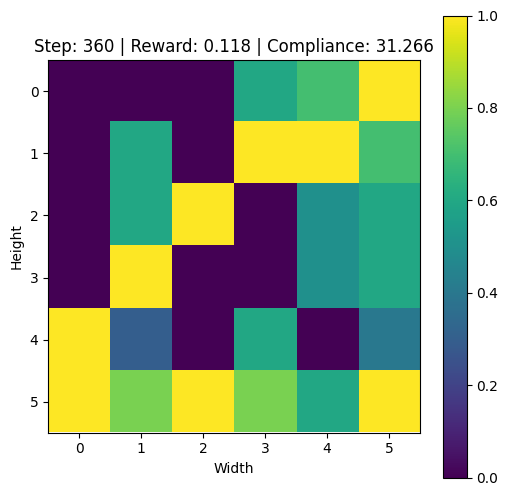

Episode: 1 		 Reward: 22.54


2025-01-01 15:35:32,885 - INFO - Episode done: Step: 360 | Action: 69 | Raw Reward: 0.13 | Scaled Reward: 0.1183 | Reward Compliance: -0.32 | Reward Density High: 0.15 | Reward Density Low: 0.15 | Reward Total Mass: -0.00 | Reward Entropy: 0.15 | Total Reward: 0.1441 | Compliance: 32.00 | Constraint: 0.49


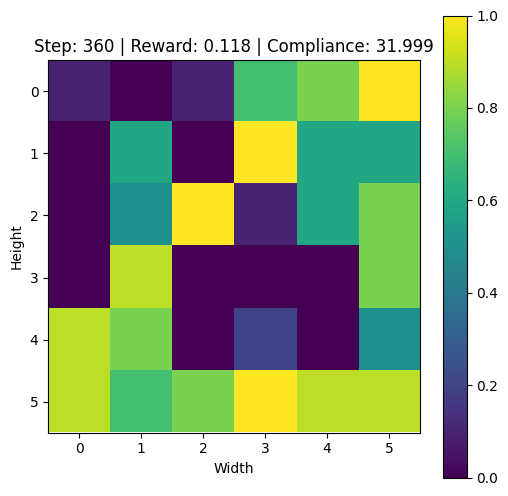

Episode: 2 		 Reward: 21.01


2025-01-01 15:35:33,623 - INFO - Episode done: Step: 360 | Action: 0 | Raw Reward: 0.09 | Scaled Reward: 0.0793 | Reward Compliance: -0.36 | Reward Density High: 0.16 | Reward Density Low: 0.16 | Reward Total Mass: -0.01 | Reward Entropy: 0.14 | Total Reward: 0.1145 | Compliance: 35.72 | Constraint: 0.50


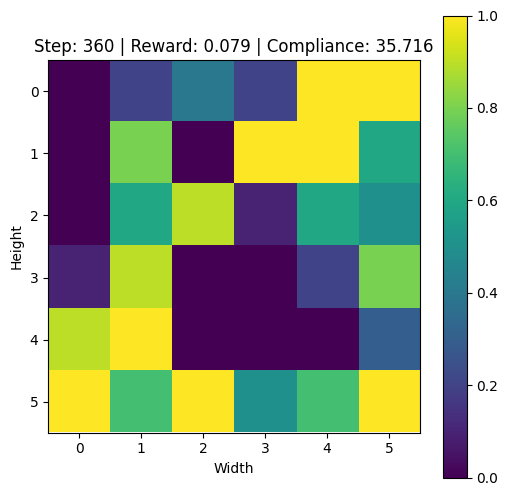

Episode: 3 		 Reward: 17.6


2025-01-01 15:35:34,241 - INFO - Episode done: Step: 360 | Action: 52 | Raw Reward: 0.12 | Scaled Reward: 0.1062 | Reward Compliance: -0.33 | Reward Density High: 0.15 | Reward Density Low: 0.15 | Reward Total Mass: -0.00 | Reward Entropy: 0.15 | Total Reward: 0.1351 | Compliance: 32.73 | Constraint: 0.50


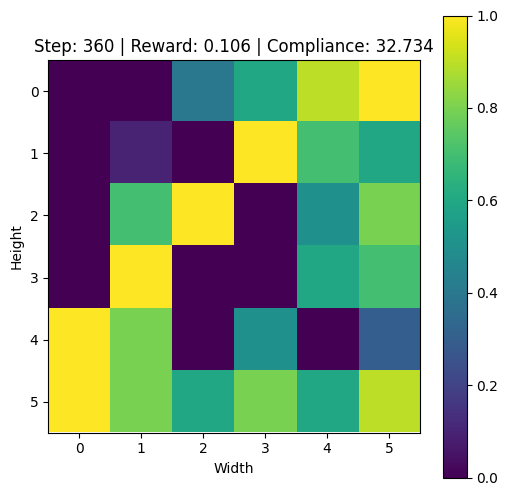

Episode: 4 		 Reward: 7.46


2025-01-01 15:35:34,884 - INFO - Episode done: Step: 360 | Action: 9 | Raw Reward: 0.11 | Scaled Reward: 0.0953 | Reward Compliance: -0.34 | Reward Density High: 0.14 | Reward Density Low: 0.14 | Reward Total Mass: -0.00 | Reward Entropy: 0.16 | Total Reward: 0.1268 | Compliance: 34.08 | Constraint: 0.50


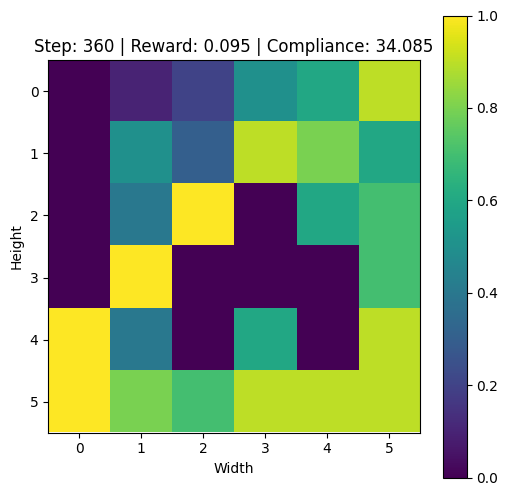

Episode: 5 		 Reward: 6.36


2025-01-01 15:35:35,828 - INFO - Episode done: Step: 360 | Action: 13 | Raw Reward: 0.14 | Scaled Reward: 0.1192 | Reward Compliance: -0.32 | Reward Density High: 0.15 | Reward Density Low: 0.15 | Reward Total Mass: -0.00 | Reward Entropy: 0.15 | Total Reward: 0.1448 | Compliance: 32.04 | Constraint: 0.49


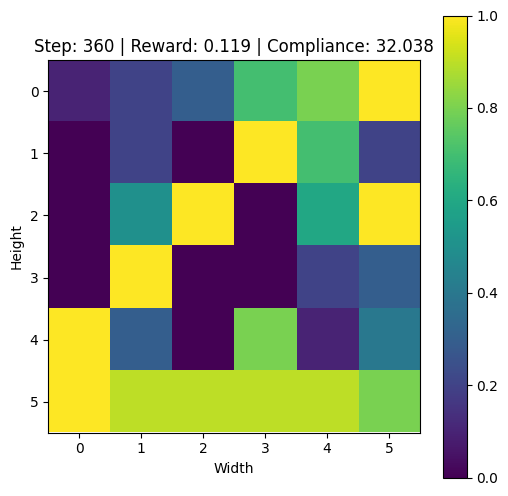

Episode: 6 		 Reward: 22.35


2025-01-01 15:35:36,453 - INFO - Episode done: Step: 360 | Action: 15 | Raw Reward: 0.14 | Scaled Reward: 0.1227 | Reward Compliance: -0.31 | Reward Density High: 0.16 | Reward Density Low: 0.16 | Reward Total Mass: -0.00 | Reward Entropy: 0.13 | Total Reward: 0.1473 | Compliance: 31.04 | Constraint: 0.49


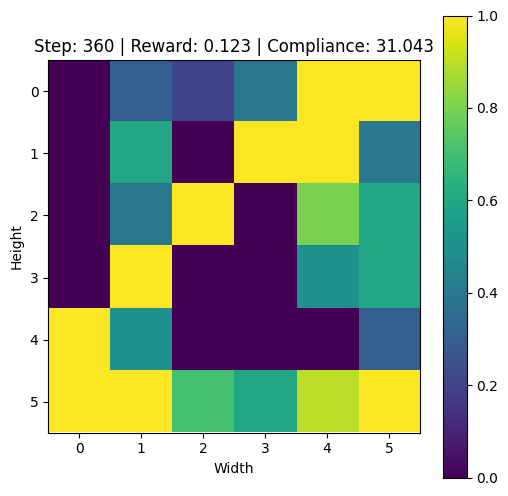

Episode: 7 		 Reward: 17.38


2025-01-01 15:35:37,080 - INFO - Episode done: Step: 360 | Action: 28 | Raw Reward: 0.14 | Scaled Reward: 0.1223 | Reward Compliance: -0.30 | Reward Density High: 0.16 | Reward Density Low: 0.16 | Reward Total Mass: -0.01 | Reward Entropy: 0.13 | Total Reward: 0.1470 | Compliance: 30.49 | Constraint: 0.50


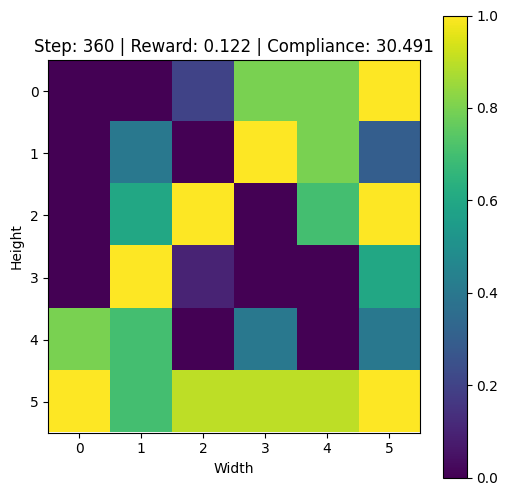

Episode: 8 		 Reward: 15.44


2025-01-01 15:35:37,716 - INFO - Episode done: Step: 360 | Action: 0 | Raw Reward: 0.07 | Scaled Reward: 0.0680 | Reward Compliance: -0.38 | Reward Density High: 0.15 | Reward Density Low: 0.15 | Reward Total Mass: -0.00 | Reward Entropy: 0.15 | Total Reward: 0.1056 | Compliance: 37.64 | Constraint: 0.50


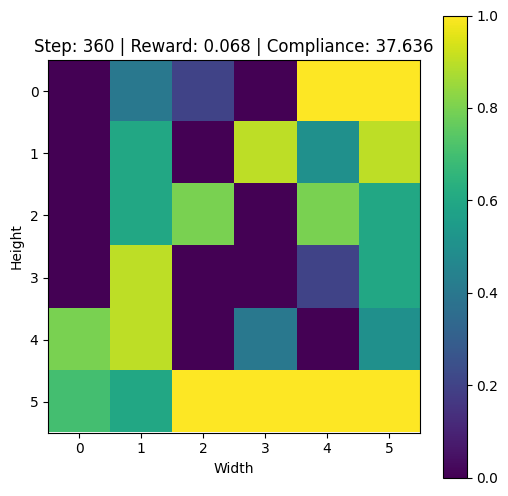

Episode: 9 		 Reward: 22.9
Average test reward: 15.30


In [11]:


print("============================================================================================")


#################################### Testing ###################################


################## hyperparameters ##################

env_name = "BeamOptimizationEnv"
has_continuous_action_space = False
max_ep_len = 1000
action_std = None




total_test_episodes = 10    # total num of testing episodes


K_epochs = best_params['K_epochs']
eps_clip = best_params['eps_clip']
gamma = best_params['gamma']
lr_actor = best_params['lr_actor']
lr_critic = best_params['lr_critic']

#####################################################


env = mbb.BeamOptimizationEnv(width=6, height=6, beam_type=5)

state_dim = env.observation_space.shape[0]
print(f" state dim is {state_dim}")

if has_continuous_action_space:
    action_dim = env.action_space.shape[0]
else:
    action_dim = env.action_space.n
print(f" action dim is {action_dim}")


ppo_agent = ppo.PPO(
        state_dim=state_dim,
        action_dim=action_dim,
        lr_actor=lr_actor,
        lr_critic=lr_critic,
        gamma=gamma,
        K_epochs=K_epochs,
        eps_clip=eps_clip,
        has_continuous_action_space=has_continuous_action_space,
        action_std_init=action_std,
        gae_lambda=0.95,
        num_envs=num_envs,
        device=device
    )


# preTrained weights directory

random_seed = 0             
run_num_pretrained = 0      


directory = "PPO_preTrained" + '/' + env_name + '/'
checkpoint_path = directory + "PPO_{}_{}_{}.pth".format(env_name, random_seed, run_num_pretrained)
print("loading network from : " + checkpoint_path)

ppo_agent.load(checkpoint_path)

print("--------------------------------------------------------------------------------------------")



test_running_reward = 0

for ep in range(1, total_test_episodes+1):
    ep_reward = 0
    state,_ = env.reset()
    for t in range(1, max_ep_len+1):
        action,_,_ = ppo_agent.select_action(state)
        state, reward, done, truncated, info = env.step(action)
        ep_reward += reward
        
        if done:
            print(f"number of changed cells in the episode is {info['num_of_changed_cells']}")
            break

    # clear buffer    
    ppo_agent.buffer.clear()

    test_running_reward +=  ep_reward
    print('Episode: {} \t\t Reward: {}'.format(ep, round(ep_reward, 2)))
    ep_reward = 0

env.close()


print("============================================================================================")

avg_test_reward = test_running_reward / total_test_episodes
avg_test_reward = round(avg_test_reward, 2)
print("average test reward : " + str(avg_test_reward))

print("============================================================================================")

import os
import pandas as pd
import matplotlib.pyplot as plt

print("============================================================================================")

env_name = 'BeamOptimizationEnv'

fig_num = 0     #### change this to prevent overwriting figures in same env_name folder

plot_avg = True    # plot average of all runs; else plot all runs separately

fig_width = 10
fig_height = 6

# smooth out rewards to get a smooth and a less smooth (var) plot lines
window_len_smooth = 50
min_window_len_smooth = 1
linewidth_smooth = 1.5
alpha_smooth = 1

window_len_var = 5
min_window_len_var = 1
linewidth_var = 2
alpha_var = 0.1

colors = ['red', 'blue', 'green', 'orange', 'purple', 'olive', 'brown', 'magenta', 'cyan', 'crimson', 'gray', 'black']

# make directory for saving figures
figures_dir = "PPO_figs"
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir)

# make environment directory for saving figures
figures_dir = figures_dir + '/' + env_name + '/'
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir)

fig_save_path = figures_dir + '/PPO_' + env_name + '_fig_' + str(fig_num) + '.png'

# get number of log files in directory
log_dir = "PPO_logs" + '/' + env_name + '/'
current_num_files = next(os.walk(log_dir))[2]
num_runs = len(current_num_files)

all_runs = []

for run_num in range(num_runs):
    log_f_name = log_dir + '/PPO_' + env_name + "_log_" + str(run_num) + ".csv"
    print("loading data from : " + log_f_name)
    if os.path.getsize(log_f_name) > 0:  
        data = pd.read_csv(log_f_name)
        data = pd.DataFrame(data)
        print("data shape : ", data.shape)
        all_runs.append(data)
    else:
        print(f"File {log_f_name} is empty. Skipping.")
    print("--------------------------------------------------------------------------------------------")

ax = plt.gca()

if plot_avg:
    # average all runs
    if all_runs:
        df_concat = pd.concat(all_runs)
        df_concat_groupby = df_concat.groupby(df_concat.index)
        data_avg = df_concat_groupby.mean()

        # smooth out rewards to get a smooth and a less smooth (var) plot lines
        data_avg['reward_smooth'] = data_avg['reward'].rolling(window=window_len_smooth, win_type='triang', min_periods=min_window_len_smooth).mean()
        data_avg['reward_var'] = data_avg['reward'].rolling(window=window_len_var, win_type='triang', min_periods=min_window_len_var).mean()

        data_avg.plot(kind='line', x='timestep', y='reward_smooth', ax=ax, color=colors[0], linewidth=linewidth_smooth, alpha=alpha_smooth)
        data_avg.plot(kind='line', x='timestep', y='reward_var', ax=ax, color=colors[0], linewidth=linewidth_var, alpha=alpha_var)

        # keep only reward_smooth in the legend and rename it
        handles, labels = ax.get_legend_handles_labels()
        ax.legend([handles[0]], ["reward_avg_" + str(len(all_runs)) + "_runs"], loc=2)
    else:
        print("No data available to plot.")
else:
    for i, run in enumerate(all_runs):
        
        run['reward_smooth_' + str(i)] = run['reward'].rolling(window=window_len_smooth, win_type='triang', min_periods=min_window_len_smooth).mean()
        run['reward_var_' + str(i)] = run['reward'].rolling(window=window_len_var, win_type='triang', min_periods=min_window_len_var).mean()


        run.plot(kind='line', x='timestep', y='reward_smooth_' + str(i), ax=ax, color=colors[i % len(colors)], linewidth=linewidth_smooth, alpha=alpha_smooth)
        run.plot(kind='line', x='timestep', y='reward_var_' + str(i), ax=ax, color=colors[i % len(colors)], linewidth=linewidth_var, alpha=alpha_var)

    handles, labels = ax.get_legend_handles_labels()
    new_handles = []
    new_labels = []
    for i in range(len(handles)):
        if i % 2 == 0:
            new_handles.append(handles[i])
            new_labels.append(labels[i])
    ax.legend(new_handles, new_labels, loc=2)

# ax.set_yticks(np.arange(0, 1800, 200))
# ax.set_xticks(np.arange(0, int(4e6), int(5e5)))

ax.grid(color='gray', linestyle='-', linewidth=1, alpha=0.2)

ax.set_xlabel("Timesteps", fontsize=12)
ax.set_ylabel("Rewards", fontsize=12)

plt.title(env_name, fontsize=14)

fig = plt.gcf()
fig.set_size_inches(fig_width, fig_height)

print("============================================================================================")

plt.savefig(fig_save_path)
print("figure saved at : ", fig_save_path)

print("============================================================================================")

plt.show()




# Hyperparameters for inference
env_name = "BeamOptimizationEnv"
has_continuous_action_space = False
max_ep_len = 1000
total_inference_episodes = 10  # Total number of inference episodes

# Initialize environment
# env = mbb.BeamOptimizationEnv(width=4, height=4, beam_type=4)
# State and action space dimensions
state_dim = env.observation_space.shape[0]
if has_continuous_action_space:
    action_dim = env.action_space.shape[0]
else:
    action_dim = env.action_space.n

# Initialize PPO agent
ppo_agent = ppo.PPO(        state_dim=state_dim,
        action_dim=action_dim,
        lr_actor=lr_actor,
        lr_critic=lr_critic,
        gamma=gamma,
        K_epochs=K_epochs,
        eps_clip=eps_clip,
        has_continuous_action_space=has_continuous_action_space,
        action_std_init=action_std,
        gae_lambda=0.95,
        num_envs=num_envs,
        device=device)
# Load pre-trained model
random_seed = 0             
run_num_pretrained = 0     
checkpoint_path = f"PPO_preTrained/{env_name}/PPO_{env_name}_{random_seed}_{run_num_pretrained}.pth"
print(f"Loading network from: {checkpoint_path}")
ppo_agent.load(checkpoint_path)

test_running_reward = 0
for ep in range(1,10):
    state,_ = env.reset()
    ep_reward = 0

    for t in range(1, max_ep_len + 1):
        action, _, _ = ppo_agent.select_action(state)
        state, reward, done, truncated, _ = env.step(action)
        ep_reward += reward
        
        #env.render()
        
        if done:
            env.render()
            break

    test_running_reward += ep_reward
    print(f'Episode: {ep} \t\t Reward: {round(ep_reward, 2)}')

avg_test_reward = test_running_reward / total_inference_episodes
print(f"Average test reward: {avg_test_reward:.2f}")

env.close()